In [2]:
import string
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
!pip install gensim
from gensim.models import Word2Vec
print("Downloading NLTK resources...")
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')
print("✅ All NLTK resources downloaded successfully!\n")
plt.style.use('default')
sns.set_palette("husl")
print("="*70)
print("📚 ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("="*70)
print("""Libraries loaded:
   • nltk - Natural Language Toolkit
   • sklearn - Feature extraction (BoW, TF-IDF)
   • gensim - Word2Vec implementation
   • pandas/matplotlib/seaborn - Data handling & visualization
""")
print("="*70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ All NLTK resources downloaded successfully!

📚 ALL LIBRARIES IMPORTED SUCCESSFULLY
Libraries loaded:
   • nltk - Natural Language Toolkit
   • sklearn - Feature extraction (BoW, TF-IDF)
   • gensim - Word2Vec implementation
   • pandas/matplotlib/seaborn - Data handling & visualization



[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


🚀 NLP TEXT PREPROCESSING & FEATURE ENGINEERING

📝 PART 1: TEXT PREPROCESSING

📄 Original Text:

Technology is evolving rapidly in the modern world! From smartphones to artificial intelligence, innovations appear everywhere. Scientists, engineers, and developers work together to solve complex problems: climate change, healthcare improvement, and efficient transportation systems. However, some people ask: “Will machines dominate human work?” The answer is uncertain; technology assists humans but cannot replace creativity, empathy, and critical thinking. Education has also changed significantly because of digital tools. Online platforms, virtual classrooms, and AI tutors help students learn faster and smarter. Teachers encourage curiosity, collaboration, and innovation; these skills are essential for the future. But one question remains: how can students balance technology and traditional learning methods? Clearly, technology should support learning—not control it!

----------------------

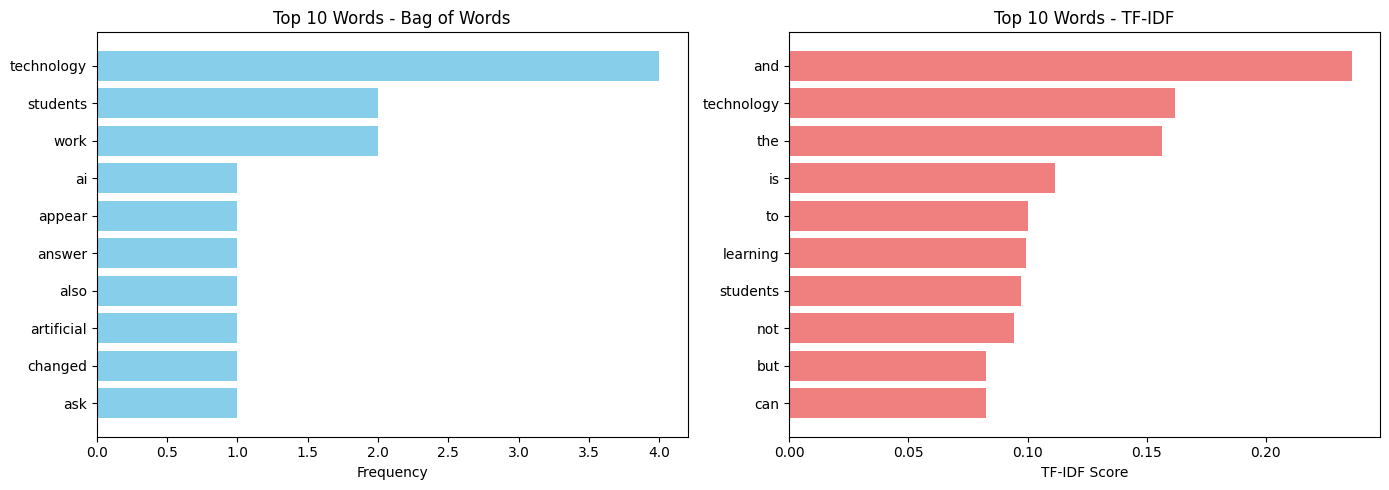


🤖 PART 3: Word2Vec IMPLEMENTATION

📊 Word2Vec Corpus Statistics:
   • Total characters: 2,459
   • Total words: 369 (✓ 200+ word requirement met)

🔧 Preprocessing Word2Vec corpus...
   • Tokens after cleaning: 235
   • Sentences created: 16

🚀 Training Word2Vec model...
   • Vocabulary size: 33 unique words

🔍 PART 4: WORD SIMILARITY ANALYSIS

📊 Cosine Similarity between word pairs:
------------------------------------------------------------
Word 1          Word 2          Similarity Score    
------------------------------------------------------------
ai              machine         0.1306
learning        intelligence    0.0506
computer        vision          0.0566
robot           human           Not in vocabulary   
technology      future          Not in vocabulary   
data            model           Not in vocabulary   
neural          network         Not in vocabulary   
algorithm       system          Not in vocabulary   
deep            learning        0.0217
natural         l

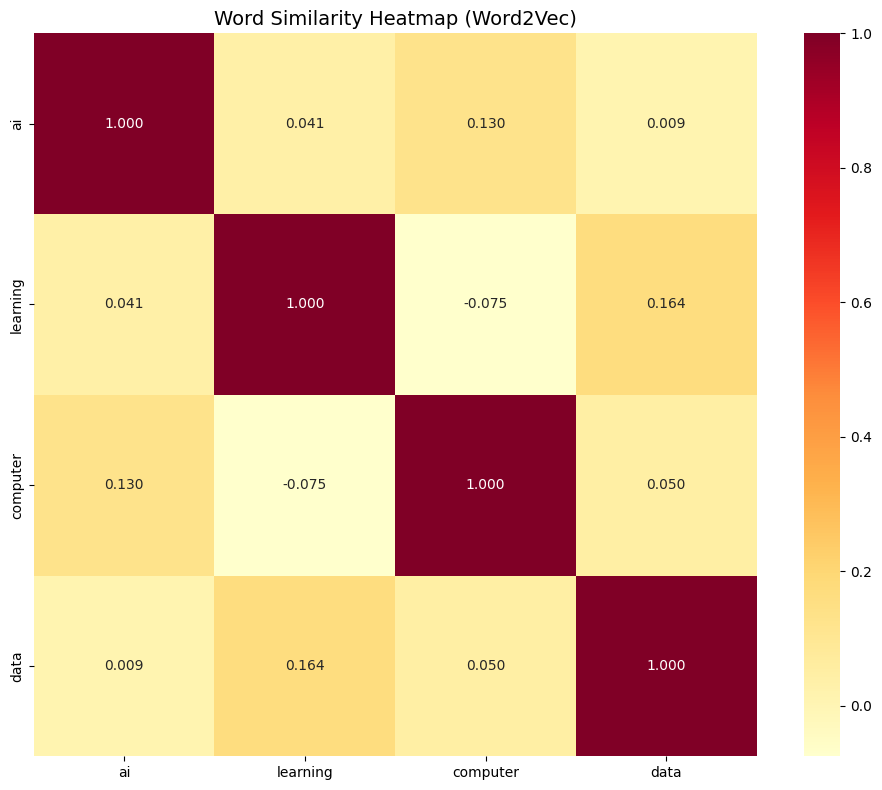


✅ COMPLETE NLP PIPELINE FINISHED SUCCESSFULLY!

📋 SUMMARY OF OPERATIONS PERFORMED:
------------------------------------
1. TEXT PREPROCESSING:
   • Punctuation removal
   • Tokenization
   • Stop word removal
   • Stemming
   • Lemmatization

2. FEATURE ENGINEERING:
   • Bag of Words (BoW) - Word frequency counting
   • TF-IDF - Term frequency-inverse document frequency

3. WORD2VEC IMPLEMENTATION:
   • Trained on 200+ word corpus
   • 100-dimensional word embeddings
   • Word pair similarity analysis
   • Similarity heatmap visualization



In [3]:
print("="*70)
print("🚀 NLP TEXT PREPROCESSING & FEATURE ENGINEERING")
print("="*70)

print("\n" + "="*70)
print("📝 PART 1: TEXT PREPROCESSING")
print("="*70)

para1 = '''Technology is evolving rapidly in the modern world! From smartphones to artificial intelligence, innovations appear everywhere. Scientists, engineers, and developers work together to solve complex problems: climate change, healthcare improvement, and efficient transportation systems. However, some people ask: “Will machines dominate human work?” The answer is uncertain; technology assists humans but cannot replace creativity, empathy, and critical thinking.'''
para2 = '''Education has also changed significantly because of digital tools. Online platforms, virtual classrooms, and AI tutors help students learn faster and smarter. Teachers encourage curiosity, collaboration, and innovation; these skills are essential for the future. But one question remains: how can students balance technology and traditional learning methods? Clearly, technology should support learning—not control it!'''

text = para1 + " " + para2

print("\n📄 Original Text:\n")
print(text)
print("\n" + "-"*70)

text_no_punct = text.translate(str.maketrans('', '', string.punctuation))
text_no_punct = re.sub(r'[”“—–]', '', text_no_punct)

print("\n📄 Text after Removing Punctuation:\n")
print(text_no_punct)
print("\n" + "-"*70)

tokens = word_tokenize(text_no_punct)
print(f"\n📊 Total tokens: {len(tokens)}")
print(f"Sample tokens: {tokens[:15]}")

stop_words = set(stopwords.words('english'))
filtered_words = [word for word in tokens if word.lower() not in stop_words]
print(f"\n📊 After Stop Word Removal: {len(filtered_words)} tokens")
print(f"Sample filtered words: {filtered_words[:15]}")

stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in filtered_words]
print(f"\n📊 After Stemming: {len(stemmed_words)} tokens")
print(f"Sample stemmed words: {stemmed_words[:15]}")

lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_words]
print(f"\n📊 After Lemmatization: {len(lemmatized_words)} tokens")
print(f"Sample lemmatized words: {lemmatized_words[:15]}")

print("\n" + "="*70)
print("📊 PART 2: FEATURE ENGINEERING - BoW & TF-IDF")
print("="*70)

cleaned_text = ' '.join(filtered_words).lower()

print("\n📊 BAG OF WORDS (BoW):")
print("-" * 40)

bow_vectorizer = CountVectorizer(max_features=20)
bow_matrix = bow_vectorizer.fit_transform([cleaned_text])

bow_features = bow_vectorizer.get_feature_names_out()
bow_counts = bow_matrix.toarray()[0]

bow_df = pd.DataFrame({
    'Word': bow_features,
    'Frequency': bow_counts
}).sort_values('Frequency', ascending=False).reset_index(drop=True)

print("\nTop 10 Words by Frequency:")
print(bow_df.head(10).to_string(index=False))

print("\n" + "-"*40)
print("📊 TF-IDF (Term Frequency-Inverse Document Frequency):")
print("-" * 40)

sentences = sent_tokenize(text)
processed_sentences = [' '.join(word_tokenize(sent.lower())) for sent in sentences]

tfidf_vectorizer = TfidfVectorizer(max_features=20)
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_sentences)

tfidf_features = tfidf_vectorizer.get_feature_names_out()
avg_tfidf_scores = tfidf_matrix.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    'Word': tfidf_features,
    'TFIDF_Score': avg_tfidf_scores
}).sort_values('TFIDF_Score', ascending=False).reset_index(drop=True)

print("\nTop 10 Words by TF-IDF Score:")
print(tfidf_df.head(10).to_string(index=False))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
top10_bow = bow_df.head(10)
plt.barh(range(len(top10_bow)), top10_bow['Frequency'], color='skyblue')
plt.yticks(range(len(top10_bow)), top10_bow['Word'])
plt.xlabel('Frequency')
plt.title('Top 10 Words - Bag of Words')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
top10_tfidf = tfidf_df.head(10)
plt.barh(range(len(top10_tfidf)), top10_tfidf['TFIDF_Score'], color='lightcoral')
plt.yticks(range(len(top10_tfidf)), top10_tfidf['Word'])
plt.xlabel('TF-IDF Score')
plt.title('Top 10 Words - TF-IDF')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("🤖 PART 3: Word2Vec IMPLEMENTATION")
print("="*70)

word2vec_corpus = '''
Artificial intelligence and machine learning are revolutionizing the technology industry.
Deep learning models, particularly neural networks, have achieved remarkable results in computer vision
and natural language processing tasks. Companies like Google, Microsoft, and Amazon are investing heavily
in AI research and development. Self-driving cars use computer vision algorithms to detect objects and
navigate safely on roads. Virtual assistants like Siri and Alexa understand human speech and respond
intelligently to queries. Healthcare applications use AI to analyze medical images and assist doctors
in diagnosing diseases. Financial institutions employ machine learning for fraud detection and risk
assessment. Recommendation systems on Netflix and Amazon suggest personalized content based on user
preferences. Natural language processing enables chatbots to have meaningful conversations with customers.
Reinforcement learning helps robots learn complex tasks through trial and error. Generative AI models
like GPT can create human-like text, images, and even music. The future of AI promises even more
breakthroughs in various fields including education, transportation, and scientific research.
However, ethical considerations about AI bias, privacy, and job displacement need careful attention.
Researchers are working on making AI systems more transparent, fair, and accountable. The collaboration
between humans and AI will shape the future of work and society. Understanding these technologies
is becoming increasingly important for professionals across all industries. Students and developers
are learning to build AI applications using frameworks like TensorFlow and PyTorch. The possibilities
with artificial intelligence seem endless, and we are just beginning to scratch the surface of what
these technologies can achieve. Machine learning algorithms continue to improve with more data and
better computational resources. Deep neural networks with multiple layers can learn hierarchical
representations of data. Natural language understanding has advanced significantly with transformer
models like BERT and GPT. Computer vision systems can now recognize objects, faces, and even emotions
with high accuracy. Robotics combines perception, planning, and control to perform complex tasks
in dynamic environments. AI ethics and responsible AI development are crucial for ensuring these
technologies benefit humanity.
'''

print(f"\n📊 Word2Vec Corpus Statistics:")
print(f"   • Total characters: {len(word2vec_corpus):,}")
words_count = len(word_tokenize(word2vec_corpus))
print(f"   • Total words: {words_count} (✓ 200+ word requirement met)")

print("\n🔧 Preprocessing Word2Vec corpus...")

w2v_tokens = word_tokenize(word2vec_corpus.lower())
w2v_tokens = [token for token in w2v_tokens if token.isalpha() and token not in stop_words]

print(f"   • Tokens after cleaning: {len(w2v_tokens)}")

sentences_for_w2v = []
for i in range(0, len(w2v_tokens), 15):
    sentence = w2v_tokens[i:i+15]
    if len(sentence) > 5:
        sentences_for_w2v.append(sentence)

print(f"   • Sentences created: {len(sentences_for_w2v)}")

print("\n🚀 Training Word2Vec model...")
w2v_model = Word2Vec(
    sentences=sentences_for_w2v,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=50
)

vocab_size = len(w2v_model.wv.key_to_index)
print(f"   • Vocabulary size: {vocab_size} unique words")

print("\n" + "="*70)
print("🔍 PART 4: WORD SIMILARITY ANALYSIS")
print("="*70)

word_pairs = [
    ('ai', 'machine'),
    ('learning', 'intelligence'),
    ('computer', 'vision'),
    ('robot', 'human'),
    ('technology', 'future'),
    ('data', 'model'),
    ('neural', 'network'),
    ('algorithm', 'system'),
    ('deep', 'learning'),
    ('natural', 'language')
]

print("\n📊 Cosine Similarity between word pairs:")
print("-" * 60)
print(f"{'Word 1':<15} {'Word 2':<15} {'Similarity Score':<20}")
print("-" * 60)

for word1, word2 in word_pairs:
    if word1 in w2v_model.wv and word2 in w2v_model.wv:
        similarity = w2v_model.wv.similarity(word1, word2)
        print(f"{word1:<15} {word2:<15} {similarity:.4f}")
    else:
        print(f"{word1:<15} {word2:<15} {'Not in vocabulary':<20}")

print("\n" + "-"*60)
print("📊 Most Similar Words for Key Terms:")
print("-" * 60)

key_terms = ['ai', 'learning', 'technology', 'computer', 'robot', 'data']
for term in key_terms:
    if term in w2v_model.wv:
        similar_words = w2v_model.wv.most_similar(term, topn=5)
        print(f"\nTop 5 words similar to '{term}':")
        for word, score in similar_words:
            print(f"   • {word}: {score:.4f}")

print("\n📈 Creating similarity heatmap...")

selected_words = ['ai', 'learning', 'technology', 'computer', 'robot',
                  'human', 'data', 'model', 'network']
available_words = [word for word in selected_words if word in w2v_model.wv]

if len(available_words) >= 3:
    similarity_matrix = np.zeros((len(available_words), len(available_words)))

    for i, word1 in enumerate(available_words):
        for j, word2 in enumerate(available_words):
            similarity_matrix[i, j] = w2v_model.wv.similarity(word1, word2)

    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity_matrix,
                xticklabels=available_words,
                yticklabels=available_words,
                annot=True,
                cmap='YlOrRd',
                fmt='.3f',
                square=True)
    plt.title('Word Similarity Heatmap (Word2Vec)', fontsize=14)
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("✅ COMPLETE NLP PIPELINE FINISHED SUCCESSFULLY!")
print("="*70)
print("""
📋 SUMMARY OF OPERATIONS PERFORMED:
------------------------------------
1. TEXT PREPROCESSING:
   • Punctuation removal
   • Tokenization
   • Stop word removal
   • Stemming
   • Lemmatization

2. FEATURE ENGINEERING:
   • Bag of Words (BoW) - Word frequency counting
   • TF-IDF - Term frequency-inverse document frequency

3. WORD2VEC IMPLEMENTATION:
   • Trained on 200+ word corpus
   • 100-dimensional word embeddings
   • Word pair similarity analysis
   • Similarity heatmap visualization
""")
print("="*70)